# Laboratorio 5: Clasificación Multiclase (One-vs-All)
**Estudiante:** Diego Leytao Espinoza Virgo
**Dataset:** OCTMNIST (Imágenes de coherencia óptica de la retina)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el archivo binario .npz utilizando NumPy
dataset = np.load('octmnist.npz')

# 2. Unificar todas las imágenes y etiquetas en un solo bloque
X_all = np.concatenate((dataset['train_images'], dataset['val_images'], dataset['test_images']))
y_all = np.concatenate((dataset['train_labels'], dataset['val_labels'], dataset['test_labels'])).ravel()

# 3. Aplanar las imágenes de 28x28 píxeles a vectores de 784 características
num_ejemplos = X_all.shape[0]
X_flat = X_all.reshape(num_ejemplos, -1)

# 4. Crear el DataFrame de Pandas para cumplir con la instructiva
columnas = [f'pixel_{i}' for i in range(X_flat.shape[1])]
df = pd.DataFrame(X_flat, columns=columnas)
df['target'] = y_all

# 5. Garantizar que el dataset esté balanceado (LÍNEA CORREGIDA)
min_clase = df['target'].value_counts().min()
df_balanceado = df.groupby('target').sample(n=min_clase, random_state=42)

print("Distribución de clases después del balanceo:")
print(df_balanceado['target'].value_counts())

# 6. Separar nuevamente en X e y
X_bal = df_balanceado.drop('target', axis=1).values
y_bal = df_balanceado['target'].values

# 7. División 80% Entrenamiento y 20% Prueba
m = len(y_bal)
train_size = int(m * 0.8)

np.random.seed(42)
indices = np.random.permutation(m)
X_shuffled = X_bal[indices]
y_shuffled = y_bal[indices]

X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_test = y_shuffled[train_size:]

# 8. Normalización (dividiendo por 255.0 al tratarse de píxeles) y agregar theta_0
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"\nDatos listos -> Entrenamiento: {X_train_norm.shape[0]} | Prueba: {X_test_norm.shape[0]}")

Distribución de clases después del balanceo:
target
0    8866
1    8866
2    8866
3    8866
Name: count, dtype: int64

Datos listos -> Entrenamiento: 28371 | Prueba: 7093


# Funciones matematicas

Iniciando entrenamiento general...
Entrenando clasificador especializado en la Clase 0...
Entrenando clasificador especializado en la Clase 1...
Entrenando clasificador especializado en la Clase 2...
Entrenando clasificador especializado en la Clase 3...


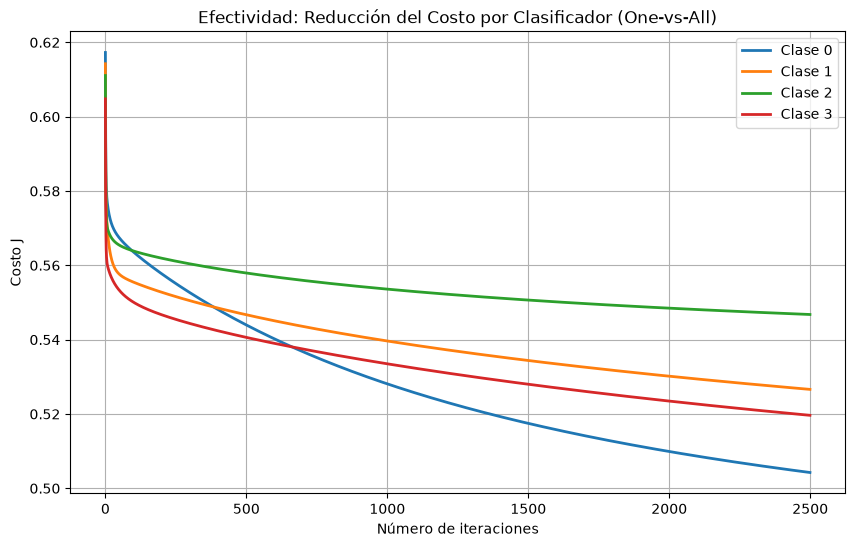

¡Entrenamiento One-vs-All completado!


In [8]:
# 1. Funciones matemáticas base (Sigmoide, Costo y Descenso por el Gradiente)
def sigmoid(z):
    z = np.clip(z, -250, 250) # Prevenir overflow
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    epsilon = 1e-5 
    J = -(1 / m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = []
    
    for i in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(calcularCosto(theta, X, y))
        
    return theta, J_history

# 2. Función principal para el entrenamiento One-vs-All
def entrenar_OneVsAll(X, y, num_labels, alpha, num_iters):
    m, n = X.shape
    # Matriz para guardar los parámetros theta de los 4 clasificadores
    all_theta = np.zeros((num_labels, n))
    
    plt.figure(figsize=(10, 6))
    
    for c in range(num_labels):
        print(f"Entrenando clasificador especializado en la Clase {c}...")
        
        # Estrategia One-vs-All: 1 si es de la clase 'c', 0 en caso contrario
        y_actual = np.where(y == c, 1, 0)
        initial_theta = np.zeros(n)
        
        # Entrenar el modelo
        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)
        all_theta[c] = theta
        
        # Graficar el costo de este clasificador
        plt.plot(np.arange(len(J_history)), J_history, lw=2, label=f'Clase {c}')
        
    plt.xlabel('Número de iteraciones')
    plt.ylabel('Costo J')
    plt.title('Efectividad: Reducción del Costo por Clasificador (One-vs-All)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return all_theta

# 3. Iniciar el entrenamiento
num_labels = 4 # Tenemos 4 clases (0, 1, 2 y 3)
alpha = 0.05    # Tasa de aprendizaje ajustada para imágenes
num_iters = 2500

print("Iniciando entrenamiento general...")
# Entrenamos usando X_train_norm y y_train
all_theta = entrenar_OneVsAll(X_train_norm, y_train, num_labels, alpha, num_iters)
print("¡Entrenamiento One-vs-All completado!")

## 3. Validación y Predicciones (One-vs-All)
Para demostrar la efectividad del modelo, utilizamos el 20% de los datos de prueba (`X_test_norm`) que fueron separados al inicio y que el modelo nunca ha visto. 

En la estrategia "Uno contra Todos", se calcula la probabilidad de que una imagen pertenezca a cada una de las 4 clases utilizando los parámetros optimizados (`all_theta`). La predicción final asignada a cada imagen será la clase que obtenga la probabilidad más alta (utilizando la función `argmax`). Finalmente, comparamos estas predicciones con las etiquetas reales (`y_test`) para calcular la precisión global del modelo.

In [9]:
# 1. Definir la función de predicción Multiclase
def predecir_OneVsAll(all_theta, X):
    # Calculamos las probabilidades para todas las clases simultáneamente
    probabilidades = sigmoid(np.dot(X, all_theta.T))
    
    # np.argmax selecciona automáticamente la clase (0, 1, 2 o 3) con la mayor probabilidad
    predicciones = np.argmax(probabilidades, axis=1)
    return predicciones

# 2. Realizar las predicciones con el 20% de datos de prueba
print("Evaluando imágenes en el conjunto de prueba...")
predicciones_test = predecir_OneVsAll(all_theta, X_test_norm)

# 3. Calcular la efectividad (precisión global)
precision = np.mean(predicciones_test == y_test) * 100
print(f"¡La precisión del modelo multiclase en los datos de prueba es: {precision:.2f}%!")

Evaluando imágenes en el conjunto de prueba...
¡La precisión del modelo multiclase en los datos de prueba es: 43.18%!
